In [2]:
import os
CUDA_VISIBLE_DEVICES=0
os.environ['CUDA_VISIBLE_DEVICES'] = f"{CUDA_VISIBLE_DEVICES}"
import torch
print(f"visible GPUs: {torch.cuda.device_count()}")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

visible GPUs: 1


# Sanity Check

The new generative frontiers analysis requiere entropies to be good estimates. We begin the analysis by comparing both.

In [3]:
## Loading Results

In [4]:
GPT2_REAL_ENTROPY_PATH = "outputs/gpt2_real_entropy_256tok/openai-community_gpt2/metrics.csv"
GPT2_MEDIUM_REAL_ENTROPY_PATH = "outputs/gpt2medium_real_entropy_256tok/openai-community_gpt2-medium/metrics.csv"
GPT2_LARGE_REAL_ENTROPY_PATH = "outputs/gpt2large_real_entropy_256tok/openai-community_gpt2-large/metrics.csv"
GPT2_XL_REAL_ENTROPY_PATH = "outputs/gpt2xl_real_entropy_256tok/openai-community_gpt2-xl/metrics.csv"

GPT2_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers_256tok/openai-community_gpt2/metrics.csv"
GPT2_MEDIUM_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers_256tok/openai-community_gpt2-medium/metrics.csv"
GPT2_LARGE_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers_256tok/openai-community_gpt2-large/metrics.csv"
GPT2_XL_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers_256tok/openai-community_gpt2-xl/metrics.csv"

df_gpt2_real_entropy = pd.read_csv(GPT2_REAL_ENTROPY_PATH)
df_gpt2_medium_real_entropy = pd.read_csv(GPT2_MEDIUM_REAL_ENTROPY_PATH)
df_gpt2_large_real_entropy = pd.read_csv(GPT2_LARGE_REAL_ENTROPY_PATH)
df_gpt2_xl_real_entropy = pd.read_csv(GPT2_XL_REAL_ENTROPY_PATH)

df_gpt2_est_entropy = pd.read_csv(GPT2_EST_ENTROPY_PATH)
df_gpt2_medium_est_entropy = pd.read_csv(GPT2_MEDIUM_EST_ENTROPY_PATH)
df_gpt2_large_est_entropy = pd.read_csv(GPT2_LARGE_EST_ENTROPY_PATH)
df_gpt2_xl_est_entropy = pd.read_csv(GPT2_XL_EST_ENTROPY_PATH)

# OWT validation set scored with Qwen/Qwen3.5-4B
# outputs/openwebtext_analysis/model_entropy/Qwen_Qwen3.5_4B/metadata.json
OWT_GEN_PPL = 14.610657533750222
OWT_MODEL_ENTROPY = 2.415385931033017
OWT_KL = np.log(OWT_GEN_PPL) - OWT_MODEL_ENTROPY

In [5]:
OWT_KL

np.float64(0.2663652994492538)

In [6]:
FILTER_COLUMNS = ["temperature", "model_entropy", "gen_ppl", "kl", "unigram_entropy"]

df_gpt2_real = df_gpt2_real_entropy[FILTER_COLUMNS]
df_gpt2_medium_real = df_gpt2_medium_real_entropy[FILTER_COLUMNS]
df_gpt2_large_real = df_gpt2_large_real_entropy[FILTER_COLUMNS]
df_gpt2_xl_real = df_gpt2_xl_real_entropy[FILTER_COLUMNS]

df_gpt2_est = df_gpt2_est_entropy[FILTER_COLUMNS]
df_gpt2_medium_est = df_gpt2_medium_est_entropy[FILTER_COLUMNS]
df_gpt2_large_est = df_gpt2_large_est_entropy[FILTER_COLUMNS]
df_gpt2_xl_est = df_gpt2_xl_est_entropy[FILTER_COLUMNS]

df_gpt2 = df_gpt2_real.merge(df_gpt2_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_medium = df_gpt2_medium_real.merge(df_gpt2_medium_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_large = df_gpt2_large_real.merge(df_gpt2_large_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_xl = df_gpt2_xl_real.merge(df_gpt2_xl_est, on="temperature",how="inner", suffixes=("_real", "_est"))

df_gpt2["kl_actual"] = np.log(df_gpt2["gen_ppl_est"]) - df_gpt2["model_entropy_real"]
df_gpt2_medium["kl_actual"] = np.log(df_gpt2_medium["gen_ppl_est"]) - df_gpt2_medium["model_entropy_real"]
df_gpt2_large["kl_actual"] = np.log(df_gpt2_large["gen_ppl_est"]) - df_gpt2_large["model_entropy_real"]
df_gpt2_xl["kl_actual"] = np.log(df_gpt2_xl["gen_ppl_est"]) - df_gpt2_xl["model_entropy_real"]

In [7]:
df_gpt2.head()

,temperature,model_entropy_real,gen_ppl_real,kl_real,unigram_entropy_real,model_entropy_est,gen_ppl_est,kl_est,unigram_entropy_est,kl_actual
0,0.600,2.465718,3.603272,-1.183876,3.737335,2.203685,4.441493,-0.712694,3.737335,-0.974727
1,0.625,2.573246,4.002372,-1.186359,3.835460,2.301550,4.992215,-0.693671,3.835460,-0.965366
2,0.650,2.675179,4.456795,-1.180749,3.939161,2.398075,5.629057,-0.670133,3.939161,-0.947237
3,0.675,2.736988,4.886396,-1.150533,4.034787,2.455203,6.252523,-0.622218,4.034787,-0.904002
4,0.700,2.822679,5.467548,-1.123848,4.125229,2.533491,7.104575,-0.572752,4.125229,-0.861940


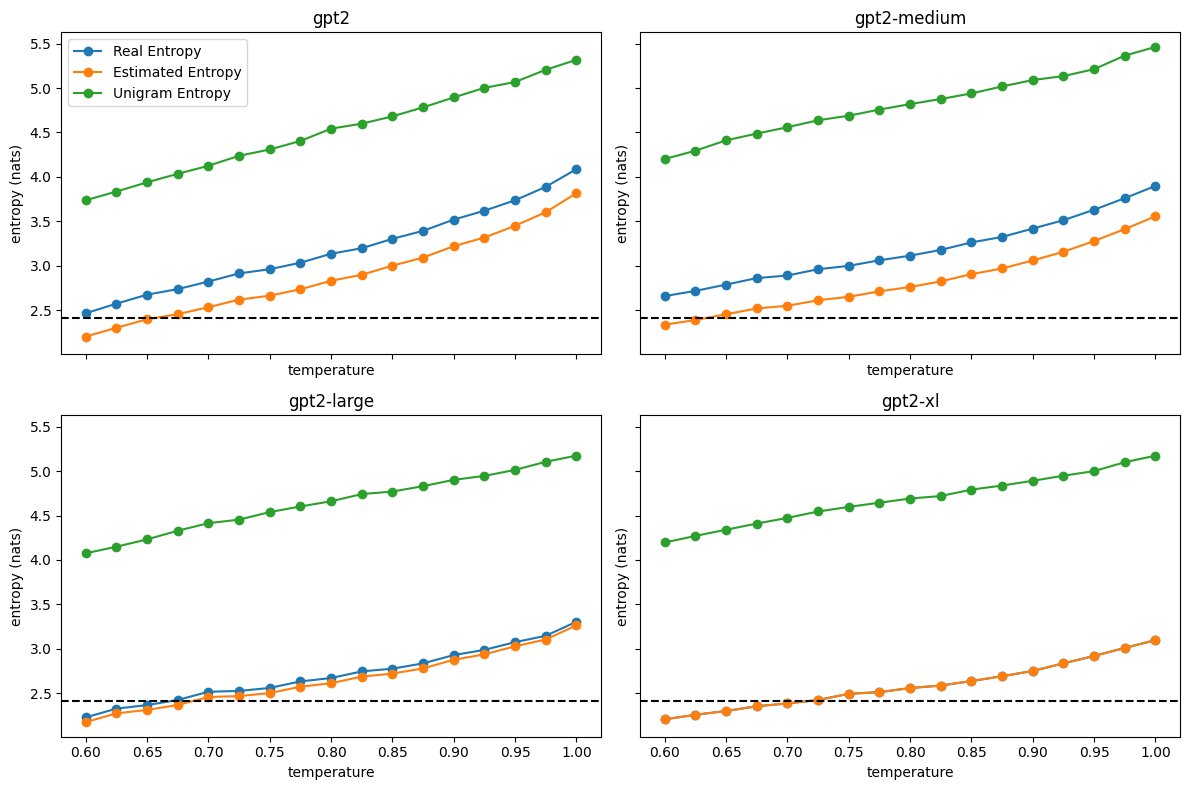

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[0, 0].set_title("gpt2")

axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[0, 1].set_title("gpt2-medium")

axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[1, 0].set_title("gpt2-large")

axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[1, 1].set_title("gpt2-xl")

for ax in axes.flatten():
    ax.axhline(y=OWT_MODEL_ENTROPY, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel("temperature")
    ax.set_ylabel("entropy (nats)")
axes[0, 0].legend()

plt.tight_layout()
plt.show()

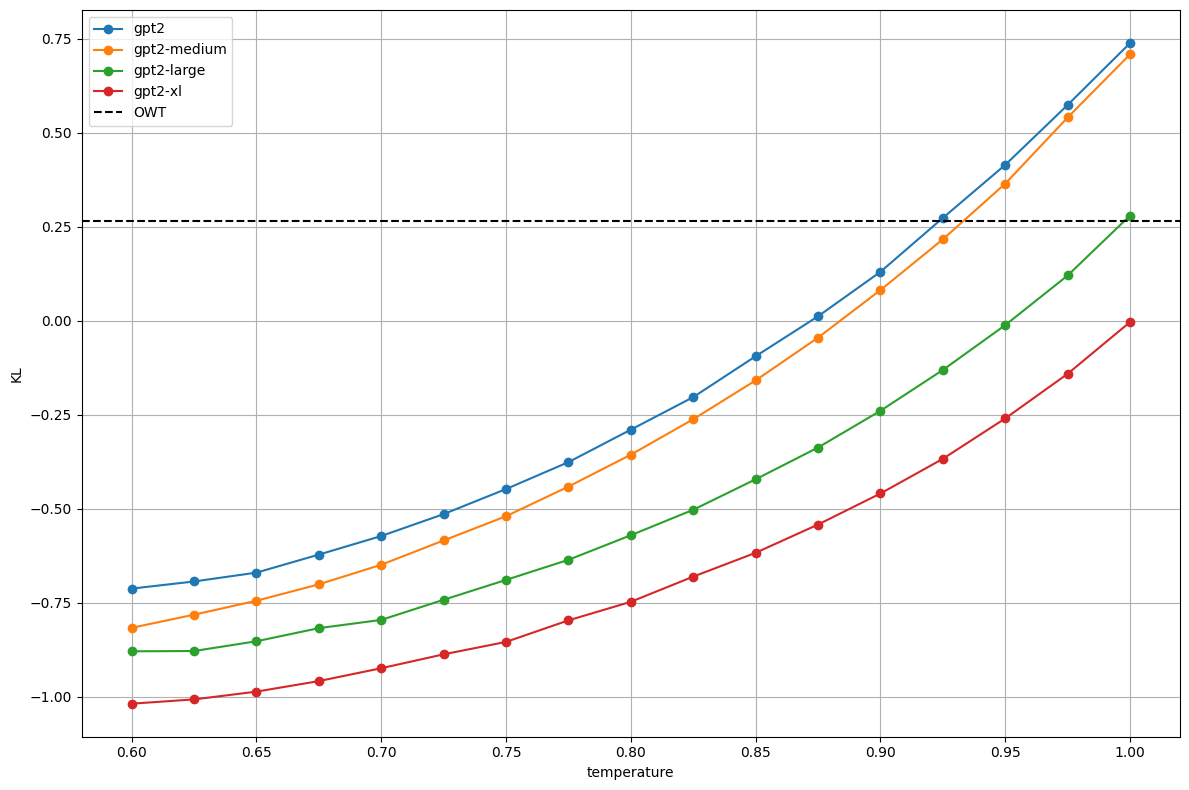

In [9]:
plt.figure(figsize=(12, 8))

plt.plot(df_gpt2["temperature"], df_gpt2["kl_est"], label="gpt2", marker= 'o')
plt.plot(df_gpt2_medium["temperature"], df_gpt2_medium["kl_est"], label="gpt2-medium", marker= 'o')
plt.plot(df_gpt2_large["temperature"], df_gpt2_large["kl_est"], label="gpt2-large", marker= 'o')
plt.plot(df_gpt2_xl["temperature"], df_gpt2_xl["kl_est"], label="gpt2-xl", marker= 'o')
plt.axhline(y=OWT_KL, color='black', linestyle='--', linewidth=1.5, label="OWT")
plt.xlabel("temperature")
plt.ylabel("KL")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

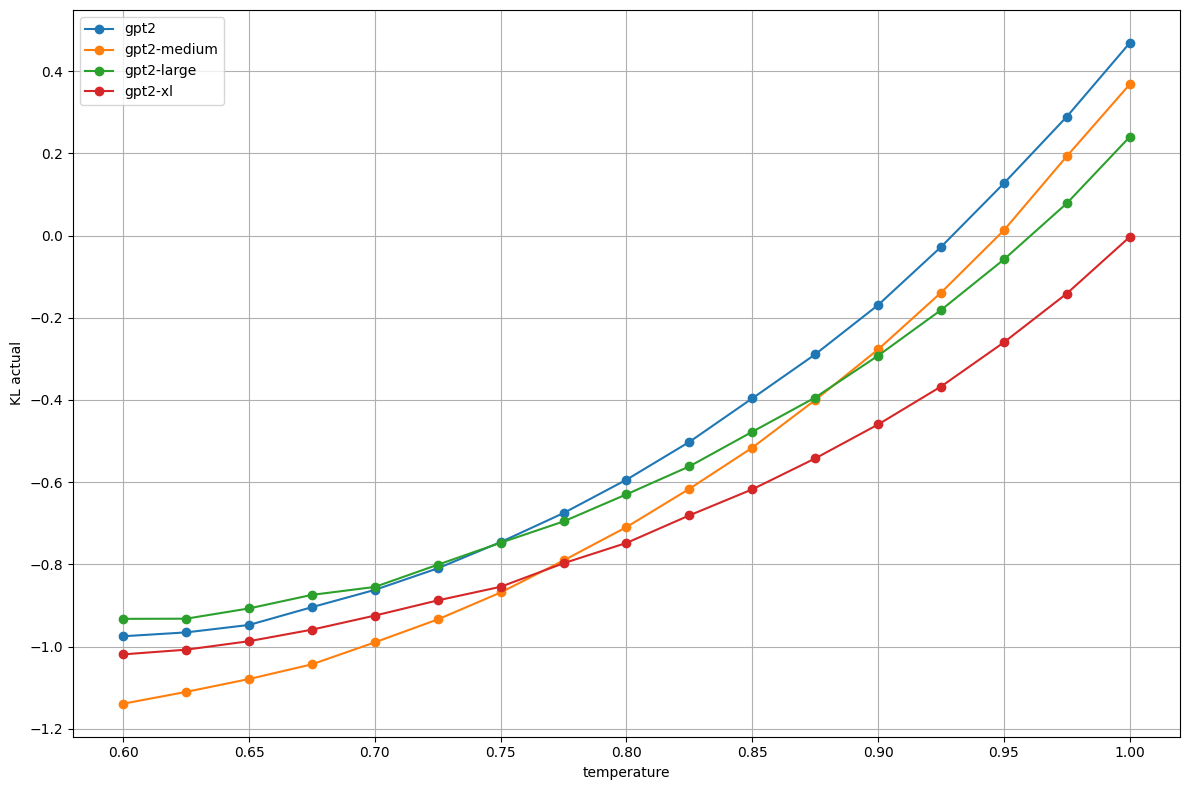

In [10]:
plt.figure(figsize=(12, 8))

plt.plot(df_gpt2["temperature"], df_gpt2["kl_actual"], label="gpt2", marker= 'o')
plt.plot(df_gpt2_medium["temperature"], df_gpt2_medium["kl_actual"], label="gpt2-medium", marker= 'o')
plt.plot(df_gpt2_large["temperature"], df_gpt2_large["kl_actual"], label="gpt2-large", marker= 'o')
plt.plot(df_gpt2_xl["temperature"], df_gpt2_xl["kl_actual"], label="gpt2-xl", marker= 'o')

plt.xlabel("temperature")
plt.ylabel("KL actual")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

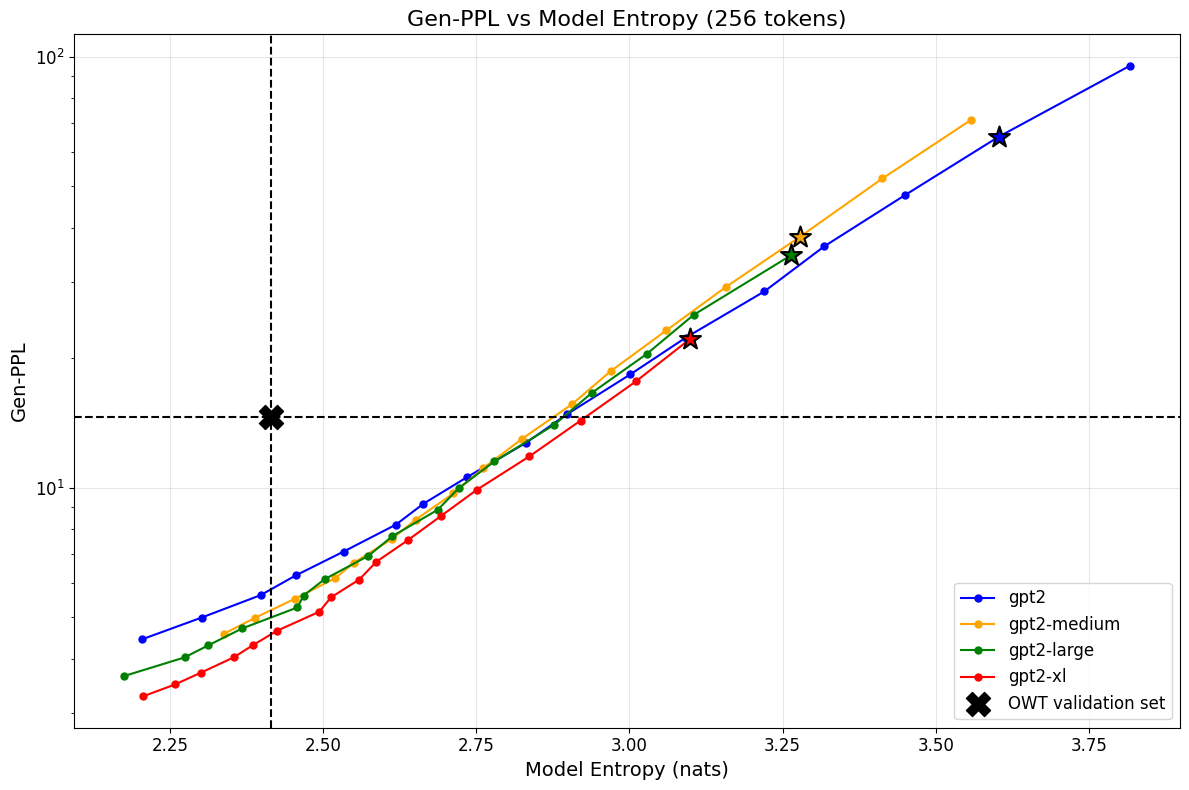

{'gpt2': np.float64(4.761796545858912),
 'gpt2-medium': np.float64(3.4868506844147147),
 'gpt2-large': np.float64(2.530270339407124),
 'gpt2-xl': np.float64(1.841708712727183)}

In [11]:
model_dfs = {
    "gpt2": df_gpt2,
    "gpt2-medium": df_gpt2_medium,
    "gpt2-large": df_gpt2_large,
    "gpt2-xl": df_gpt2_xl,
}

model_color_map = {
    "gpt2": "blue",
    "gpt2-medium": "orange",
    "gpt2-large": "green",
    "gpt2-xl": "red",
}

optimal_temp_map = {
    "gpt2": 0.975,
    "gpt2-medium": 0.95,
    "gpt2-large": 1.0,
    "gpt2-xl": 1.0,
}

fig, ax = plt.subplots(figsize=(12, 8))
auc_results = {}

for model_label, df_model in model_dfs.items():
    color = model_color_map[model_label]
    df_est = df_model.sort_values("model_entropy_est")

    ax.semilogy(df_est["model_entropy_est"], df_est["gen_ppl_est"], marker='o', markersize=5, color=color, label=model_label)

    auc_results[model_label] = np.trapezoid(y=np.log(df_est["gen_ppl_est"]), x=df_est["model_entropy_est"])

    target_temp = optimal_temp_map[model_label]
    optimal_row = df_model[np.isclose(df_model["temperature"], target_temp)]
    ax.scatter(optimal_row["model_entropy_est"], optimal_row["gen_ppl_est"],
               marker='*', s=250, color=color, edgecolor='black', linewidth=1.5, zorder=5)

ax.axvline(x=OWT_MODEL_ENTROPY, color='black', linestyle='--', linewidth=1.5)
ax.axhline(y=OWT_GEN_PPL, color='black', linestyle='--', linewidth=1.5)
ax.scatter([OWT_MODEL_ENTROPY], [OWT_GEN_PPL], marker='X', s=300, color='black', zorder=6,
           label='OWT validation set')

ax.set_xlabel("Model Entropy (nats)", fontsize=14)
ax.set_ylabel("Gen-PPL", fontsize=14)
ax.set_title("Gen-PPL vs Model Entropy (256 tokens)", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

auc_results
